# Spatial Suitability Recommendation System for Personal Care Services in Kigali
## Model Development Notebook

**Researcher:** Alliance Dushime Zirimwabagabo  
**Programme:** BSE, African Leadership University  
**Supervisor:** Bernard Lamptey  
**Grand Challenge:** Job Creation and Urbanisation

---

| Section | Content |
|---------|---------|
| 1 | Environment setup |
| 2 | Data loading and schema validation |
| 3 | Exploratory data analysis |
| 4 | Feature engineering |
| 5 | Pre-processing and spatial hold-out split |
| 6 | Logistic Regression — baseline |
| 7 | K-Nearest Neighbours |
| 8 | Random Forest — initial training |
| 9 | Hyperparameter tuning — Random Forest |
| 10 | Comparative evaluation |
| 11 | SHAP interpretability |
| 12 | Artefact serialisation |


## 1. Environment Setup

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_validate,
    RandomizedSearchCV, learning_curve,
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)
from scipy.stats import randint
import shap
import joblib
import sklearn

for lib, obj in [
    ("numpy",        np),
    ("pandas",       pd),
    ("scikit-learn", sklearn),
    ("shap",         shap),
    ("matplotlib",   matplotlib),
    ("seaborn",      sns),
]:
    print(f"{lib:<15} {obj.__version__}")


numpy           2.0.2
pandas          2.2.2
scikit-learn    1.6.1
shap            0.52.0
matplotlib      3.10.0
seaborn         0.13.2


In [2]:
PALETTE = {
    "primary": "#1B3A4B",
    "accent":  "#C8553D",
    "pos":     "#2E7D52",
    "neg":     "#B03A2E",
    "neutral": "#5A6A74",
    "grid":    "#E0DDD8",
    "text":    "#1A1A1A",
}
MODEL_COLORS = {
    "Logistic Regression":  "#1B3A4B",
    "K-Nearest Neighbours": "#C8553D",
    "Random Forest":        "#2E7D52",
}

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.edgecolor":    PALETTE["grid"],
    "axes.labelcolor":   PALETTE["text"],
    "axes.labelsize":    11,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "xtick.color":       PALETTE["text"],
    "ytick.color":       PALETTE["text"],
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "grid.color":        PALETTE["grid"],
    "grid.alpha":        0.6,
    "legend.frameon":    False,
    "legend.fontsize":   9,
    "font.family":       "DejaVu Sans",
    "figure.dpi":        110,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
})

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

def savefig(name):
    """Save figure to disk and display inline."""
    plt.savefig(FIGURES_DIR / f"{name}.png", facecolor="white")
    plt.show()

print("Configuration complete.")


Configuration complete.


## 2. Data Loading and Schema Validation

The dataset contains field-observed personal care service locations across three urban commercial clusters in Kigali — Kimironko, Remera, and Kacyiru. Each row represents one GPS-recorded business premises. Personal care services in Rwanda commonly combine hair, nail, and beauty services under one premises, so no sub-type distinction is made.

`reference_label` is a **data construction filter**:
- **1 (positive reference)** — location operating continuously for more than 12 months with observable customer activity.
- **0 (negative reference)** — premises closed or no observable customer activity within the past 12 months.

These labels define which field-observed locations are used to build the spatial reference set the model learns from. They are not predicted outcomes.

Proximity features use a four-level encoding derived from PostGIS `ST_Distance`:

| Level | Distance band |
|-------|--------------|
| 0 | 0–50 m (Very Close) |
| 1 | 50–150 m (Close) |
| 2 | 150–400 m (Moderate) |
| 3 | > 400 m (Far) |


In [8]:
DATA_PATH = "kigali_personal_care_dataset.csv"
df = pd.read_csv(DATA_PATH)

CLUSTER_MAP = {0: "Kimironko", 1: "Remera", 2: "Kacyiru"}
TARGET      = "reference_label"

df["cluster_name"] = df["cluster"].map(CLUSTER_MAP)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Records                : {len(df)}")
print(f"Features               : {df.shape[1] - 2}")  # excl cluster, cluster_name
print(f"Missing values         : {df.isnull().sum().sum()}")
print(f"\nReference label distribution:")
print(df[TARGET].value_counts()
      .rename({1: "Positive references", 0: "Negative references"}).to_string())
print(f"Positive rate          : {df[TARGET].mean()*100:.1f}%")
print(f"\nCluster distribution:")
print(df["cluster_name"].value_counts().to_string())


DATASET OVERVIEW
Records                : 187
Features               : 12
Missing values         : 0

Reference label distribution:
reference_label
Positive references    138
Negative references     49
Positive rate          : 73.8%

Cluster distribution:
cluster_name
Kimironko    85
Remera       60
Kacyiru      42


In [9]:
SCHEMA = {
    "comp_count_300":  ("int64",   (0, 100)),
    "comp_count_500":  ("int64",   (0, 150)),
    "comp_count_1k":   ("int64",   (0, 300)),
    "traffic_morning": ("int64",   (0, 400)),
    "traffic_midday":  ("int64",   (0, 500)),
    "traffic_evening": ("int64",   (0, 400)),
    "dist_transport":  ("int64",   (0, 3)),
    "dist_market":     ("int64",   (0, 3)),
    "dist_road":       ("int64",   (0, 3)),
    "pop_density":     ("float64", (0, 2000)),
    "road_type":       ("int64",   (0, 1)),
    "reference_label": ("int64",   (0, 1)),
}

print("Schema validation (Research Proposal — Table 5):")
all_ok = True
for col, (dtype, (lo, hi)) in SCHEMA.items():
    ok = df[col].between(lo, hi).all()
    if not ok:
        all_ok = False
    print(f"  {col:<22} range=[{lo},{hi}]  {'OK' if ok else 'FAIL'}")
print(f"\nAll checks passed: {all_ok}")


Schema validation (Research Proposal — Table 5):
  comp_count_300         range=[0,100]  OK
  comp_count_500         range=[0,150]  OK
  comp_count_1k          range=[0,300]  OK
  traffic_morning        range=[0,400]  OK
  traffic_midday         range=[0,500]  OK
  traffic_evening        range=[0,400]  OK
  dist_transport         range=[0,3]  OK
  dist_market            range=[0,3]  OK
  dist_road              range=[0,3]  OK
  pop_density            range=[0,2000]  OK
  road_type              range=[0,1]  OK
  reference_label        range=[0,1]  OK

All checks passed: True


In [10]:
print("Descriptive statistics — continuous features:")
continuous = [
    "comp_count_300", "comp_count_500", "comp_count_1k",
    "traffic_morning", "traffic_midday", "traffic_evening", "pop_density",
]
df[continuous].describe().round(2)


Descriptive statistics — continuous features:


,comp_count_300,comp_count_500,comp_count_1k,traffic_morning,traffic_midday,traffic_evening,pop_density
count,187.00,187.00,187.00,187.00,187.00,187.0,187.00
mean,5.84,14.56,33.41,46.48,73.97,60.4,349.97
std,3.70,6.69,13.82,18.42,29.37,22.3,101.53
min,0.00,0.00,9.00,15.00,13.00,16.0,133.40
25%,3.00,10.00,22.00,32.50,47.50,43.0,268.60
50%,5.00,13.00,32.00,45.00,72.00,60.0,344.10
75%,9.00,19.00,43.00,59.50,97.00,79.0,417.50
max,15.00,30.00,76.00,101.00,162.00,117.0,596.40


## 3. Exploratory Data Analysis

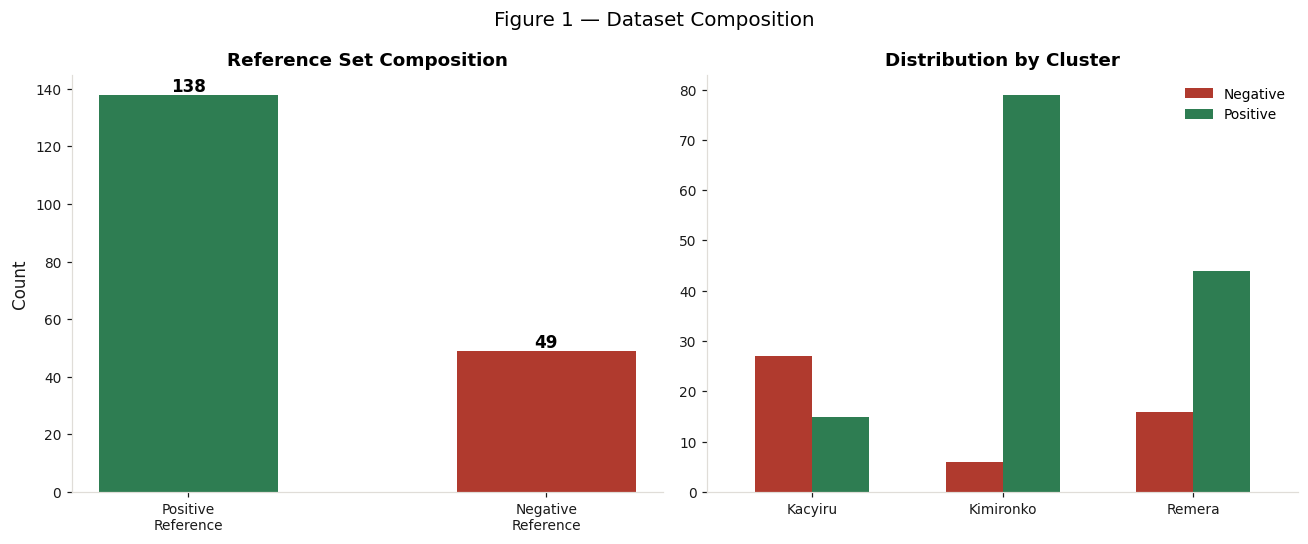

In [11]:
# Figure 1 — Dataset composition
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Figure 1 — Dataset Composition", fontsize=13)

counts = df[TARGET].value_counts().reindex([1, 0])
bars = axes[0].bar(
    ["Positive\nReference", "Negative\nReference"],
    counts.values,
    color=[PALETTE["pos"], PALETTE["neg"]], width=0.5, edgecolor="none",
)
axes[0].set_title("Reference Set Composition")
axes[0].set_ylabel("Count")
for b in bars:
    axes[0].text(
        b.get_x() + b.get_width() / 2, b.get_height() + 1.2,
        str(int(b.get_height())), ha="center", fontweight="bold", fontsize=11,
    )

ct = df.groupby(["cluster_name", TARGET]).size().unstack(fill_value=0)
ct.plot(kind="bar", ax=axes[1],
        color=[PALETTE["neg"], PALETTE["pos"]], width=0.6, edgecolor="none")
axes[1].set_title("Distribution by Cluster")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(["Negative", "Positive"])

plt.tight_layout()
savefig("fig01_dataset_composition")


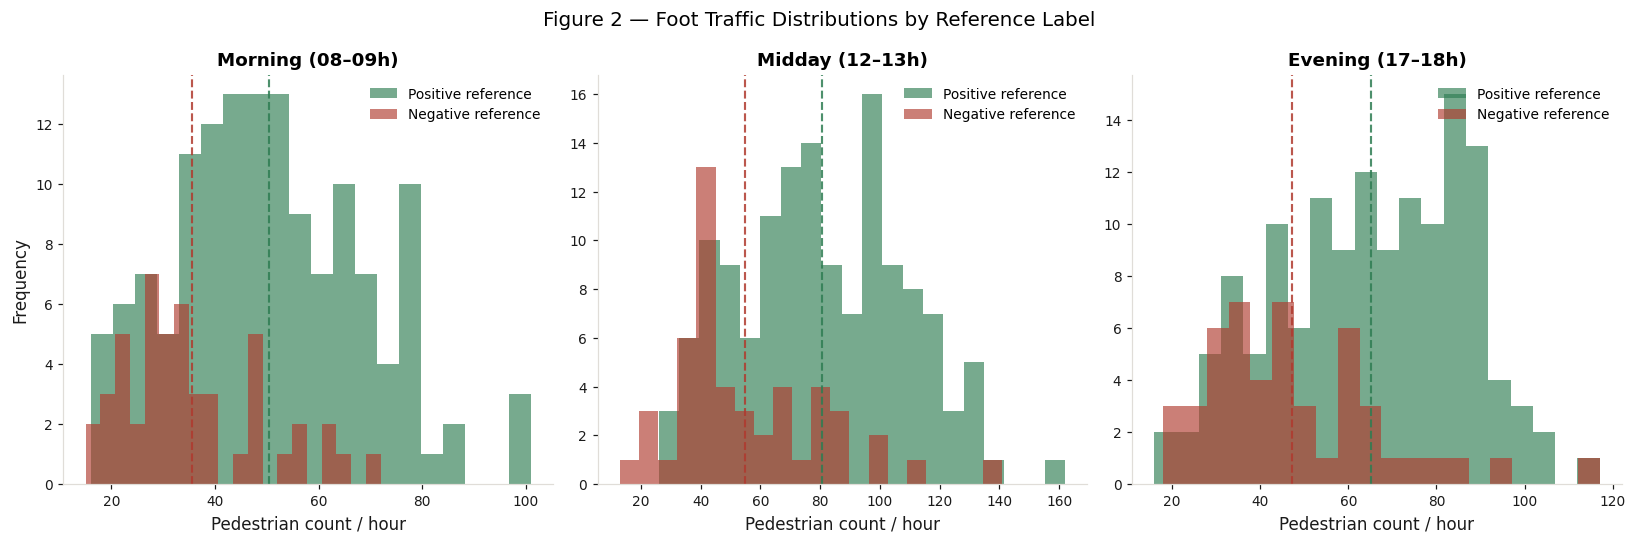

Median foot traffic by reference label:
  Morning (08–09h)          Positive: 49   Negative: 33   Delta: +16
  Midday (12–13h)           Positive: 79   Negative: 45   Delta: +34
  Evening (17–18h)          Positive: 65   Negative: 44   Delta: +21


In [12]:
# Figure 2 — Foot traffic distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Figure 2 — Foot Traffic Distributions by Reference Label", fontsize=13)

windows = [
    ("traffic_morning", "Morning (08–09h)"),
    ("traffic_midday",  "Midday (12–13h)"),
    ("traffic_evening", "Evening (17–18h)"),
]
for ax, (col, title) in zip(axes, windows):
    for val, color, name in [
        (1, PALETTE["pos"], "Positive reference"),
        (0, PALETTE["neg"], "Negative reference"),
    ]:
        data = df.loc[df[TARGET] == val, col]
        ax.hist(data, bins=20, alpha=0.65, color=color,
                label=name, edgecolor="none")
        ax.axvline(data.mean(), color=color, linestyle="--",
                   linewidth=1.4, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("Pedestrian count / hour")
    ax.set_ylabel("Frequency" if ax is axes[0] else "")
    ax.legend()

plt.tight_layout()
savefig("fig02_traffic_distributions")

print("Median foot traffic by reference label:")
for col, title in windows:
    p = df.loc[df[TARGET] == 1, col].median()
    n = df.loc[df[TARGET] == 0, col].median()
    print(f"  {title:<24}  Positive: {p:.0f}   Negative: {n:.0f}   Delta: +{p-n:.0f}")


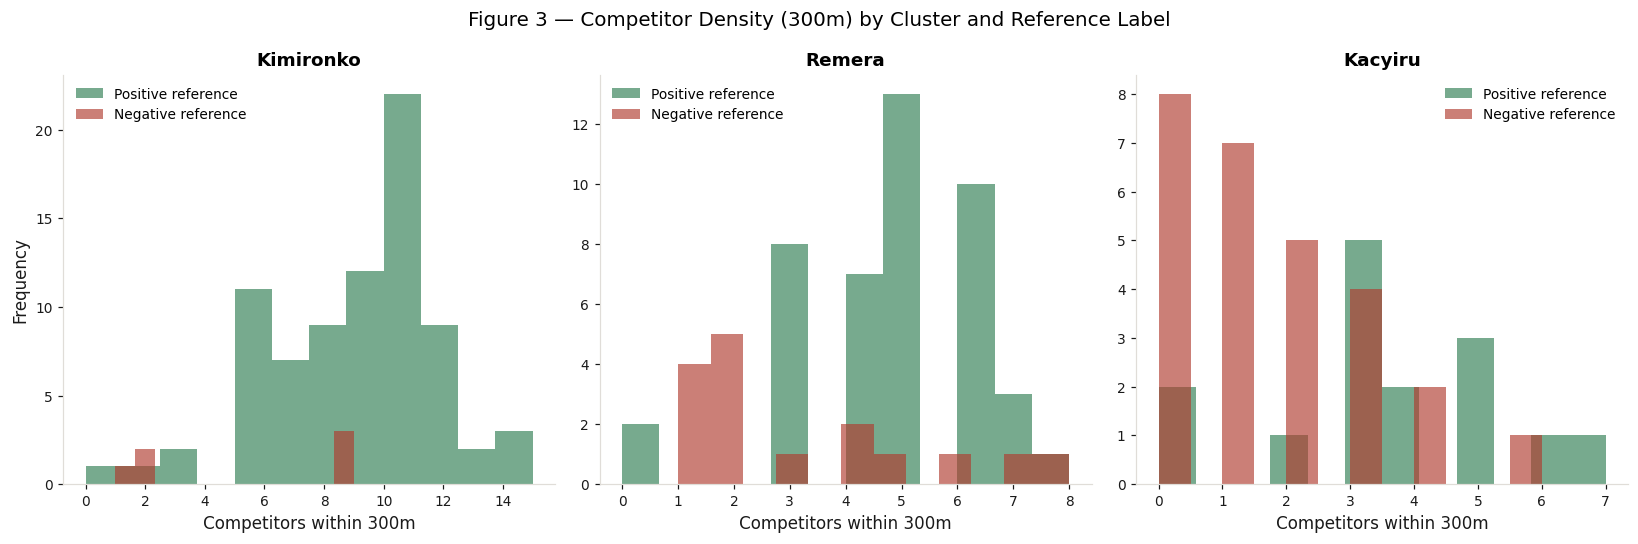

In [13]:
# Figure 3 — Competitor density at 300m by cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Figure 3 — Competitor Density (300m) by Cluster and Reference Label",
             fontsize=13)

for ax, (cid, cname) in zip(axes, CLUSTER_MAP.items()):
    sub = df[df["cluster"] == cid]
    for val, color, name in [
        (1, PALETTE["pos"], "Positive reference"),
        (0, PALETTE["neg"], "Negative reference"),
    ]:
        ax.hist(sub.loc[sub[TARGET] == val, "comp_count_300"],
                bins=12, alpha=0.65, color=color, label=name, edgecolor="none")
    ax.set_title(cname)
    ax.set_xlabel("Competitors within 300m")
    ax.set_ylabel("Frequency" if ax is axes[0] else "")
    ax.legend()

plt.tight_layout()
savefig("fig03_competition_density")


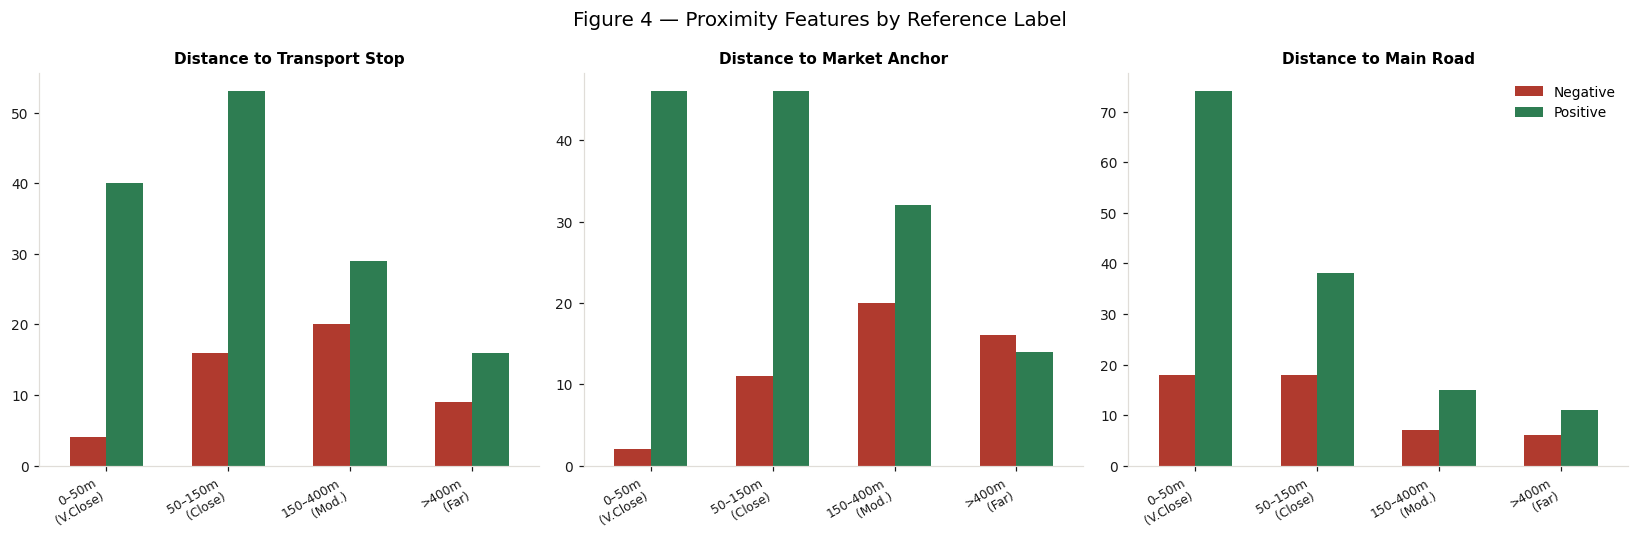

In [14]:
# Figure 4 — Proximity features
DIST_LABELS = [
    "0–50m\n(V.Close)", "50–150m\n(Close)",
    "150–400m\n(Mod.)", ">400m\n(Far)",
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Figure 4 — Proximity Features by Reference Label", fontsize=13)

for ax, (col, title) in zip(axes, [
    ("dist_transport", "Distance to Transport Stop"),
    ("dist_market",    "Distance to Market Anchor"),
    ("dist_road",      "Distance to Main Road"),
]):
    ct = df.groupby([col, TARGET]).size().unstack(fill_value=0)
    ct.index = [DIST_LABELS[i] for i in ct.index]
    ct.plot(kind="bar", ax=ax,
            color=[PALETTE["neg"], PALETTE["pos"]],
            width=0.6, edgecolor="none", legend=(ax is axes[2]))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    if ax is axes[2]:
        ax.legend(["Negative", "Positive"])

plt.tight_layout()
savefig("fig04_proximity_features")


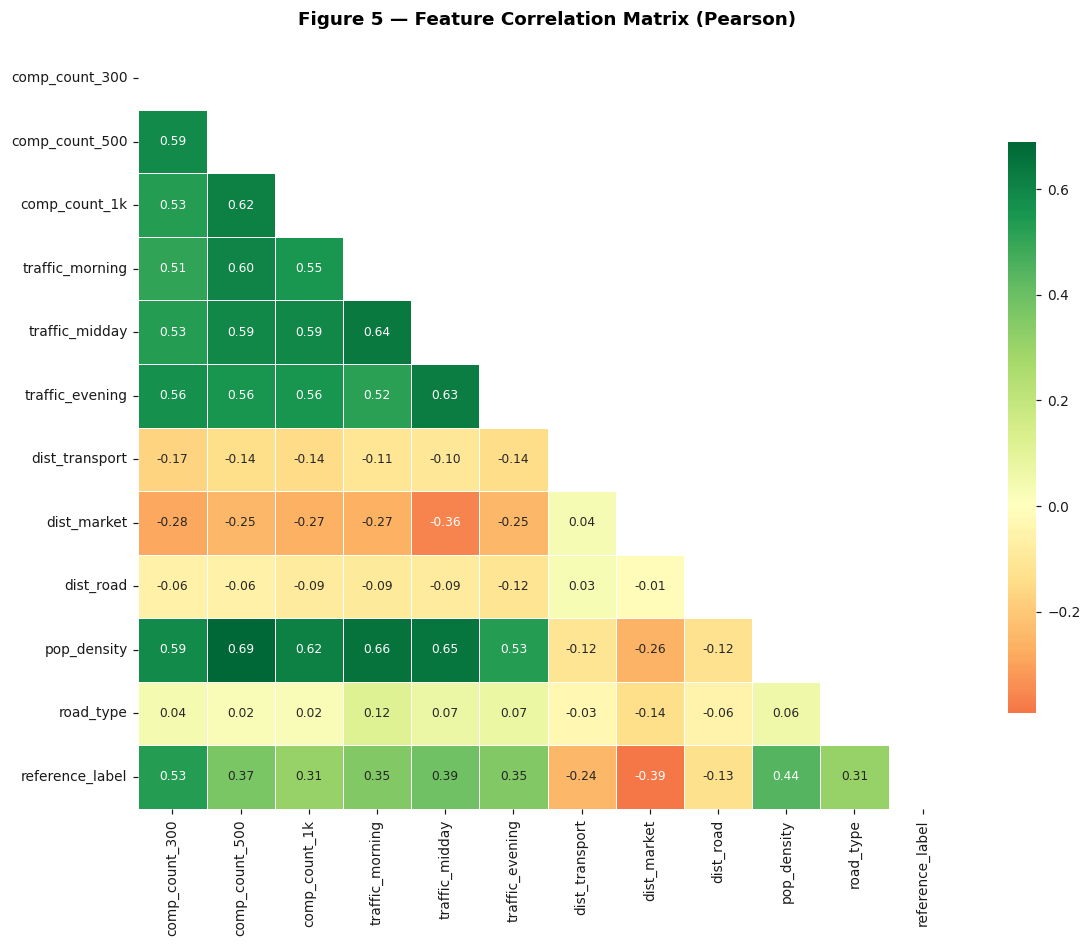

Feature correlations with reference_label (descending):
comp_count_300     0.528
pop_density        0.443
dist_market        0.393
traffic_midday     0.389
comp_count_500     0.373
traffic_morning    0.354
traffic_evening    0.354
road_type          0.309
comp_count_1k      0.307
dist_transport     0.245
dist_road          0.131


In [15]:
# Figure 5 — Correlation matrix
BASE_FEATURES = [
    "comp_count_300", "comp_count_500", "comp_count_1k",
    "traffic_morning", "traffic_midday", "traffic_evening",
    "dist_transport", "dist_market", "dist_road",
    "pop_density", "road_type",
]

fig, ax = plt.subplots(figsize=(12, 9))
corr = df[BASE_FEATURES + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, ax=ax,
    linewidths=0.5, cbar_kws={"shrink": 0.75},
    annot_kws={"size": 8},
)
ax.set_title("Figure 5 — Feature Correlation Matrix (Pearson)", pad=14)
savefig("fig05_correlation_matrix")

print("Feature correlations with reference_label (descending):")
print(corr[TARGET].drop(TARGET).abs()
      .sort_values(ascending=False).round(3).to_string())


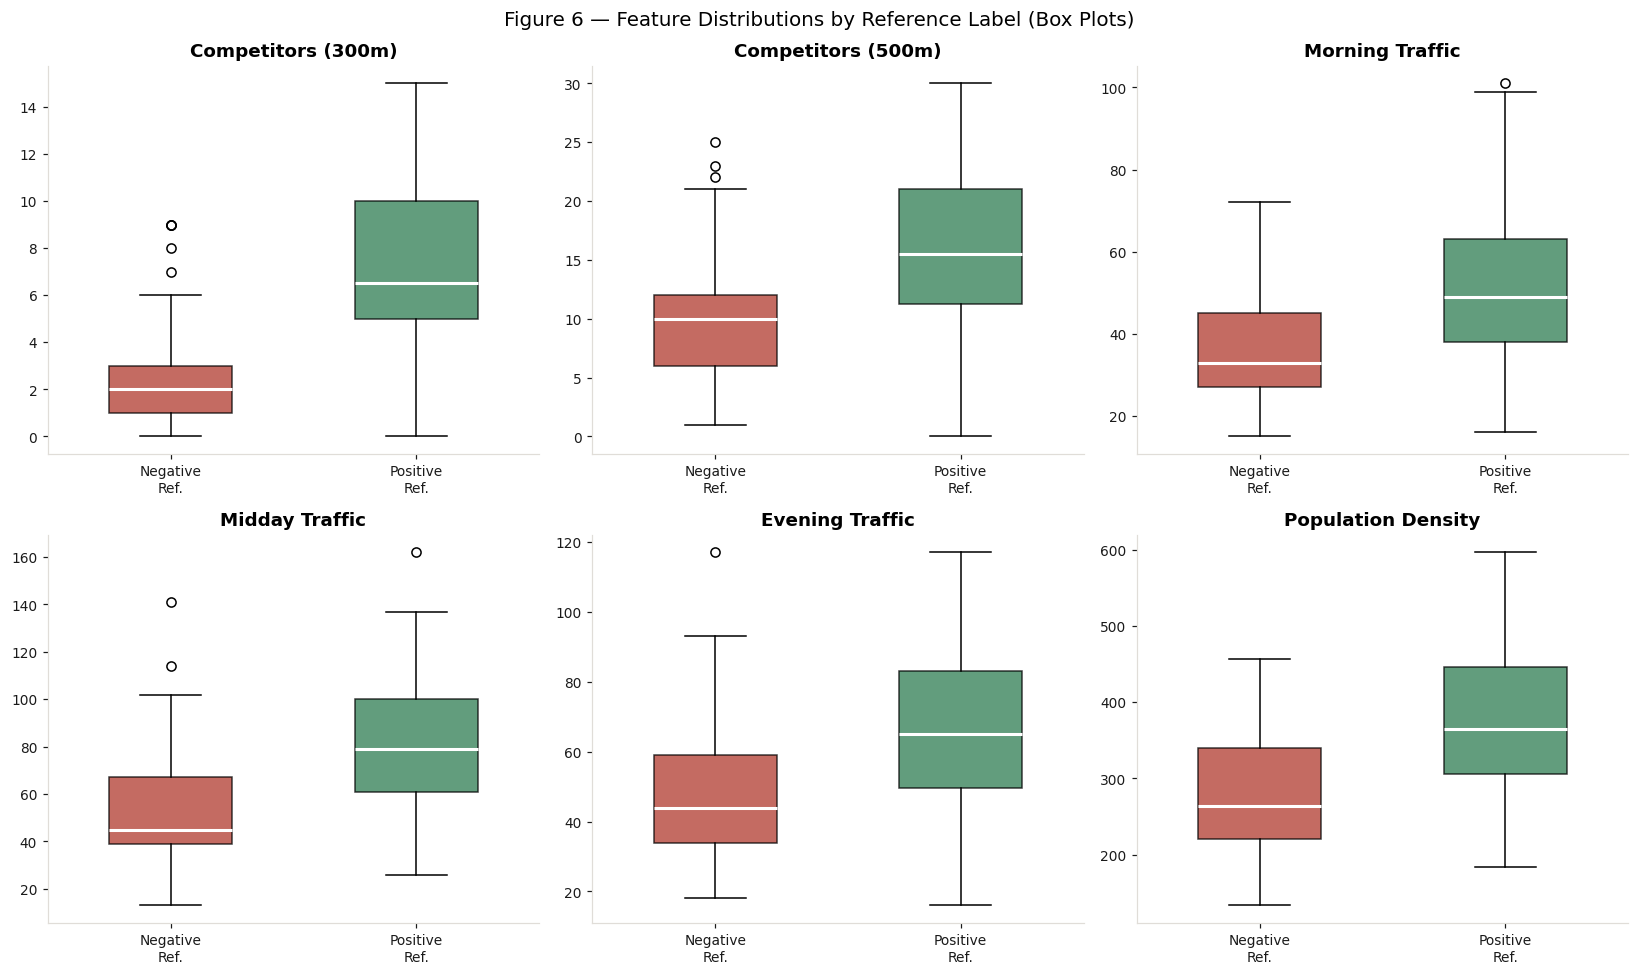

In [16]:
# Figure 6 — Box plots: continuous features by reference label
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle("Figure 6 — Feature Distributions by Reference Label (Box Plots)",
             fontsize=13)
axes = axes.flatten()

BOX_COLS = [
    ("comp_count_300",  "Competitors (300m)"),
    ("comp_count_500",  "Competitors (500m)"),
    ("traffic_morning", "Morning Traffic"),
    ("traffic_midday",  "Midday Traffic"),
    ("traffic_evening", "Evening Traffic"),
    ("pop_density",     "Population Density"),
]
for ax, (col, label) in zip(axes, BOX_COLS):
    bp = ax.boxplot(
        [df.loc[df[TARGET] == 0, col], df.loc[df[TARGET] == 1, col]],
        patch_artist=True, widths=0.5,
        medianprops={"color": "white", "linewidth": 2},
    )
    bp["boxes"][0].set_facecolor(PALETTE["neg"])
    bp["boxes"][0].set_alpha(0.75)
    bp["boxes"][1].set_facecolor(PALETTE["pos"])
    bp["boxes"][1].set_alpha(0.75)
    ax.set_xticklabels(["Negative\nRef.", "Positive\nRef."])
    ax.set_title(label)

plt.tight_layout()
savefig("fig06_boxplots")


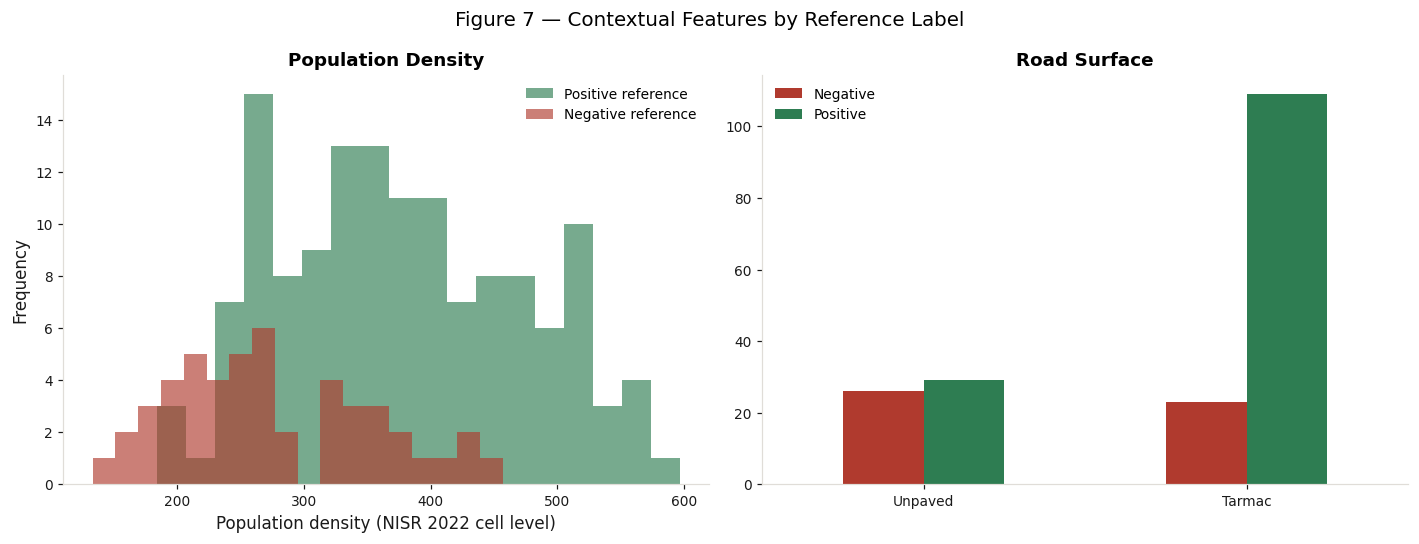

In [17]:
# Figure 7 — Population density and road surface
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Figure 7 — Contextual Features by Reference Label", fontsize=13)

for val, color, name in [
    (1, PALETTE["pos"], "Positive reference"),
    (0, PALETTE["neg"], "Negative reference"),
]:
    axes[0].hist(df.loc[df[TARGET] == val, "pop_density"],
                 bins=18, alpha=0.65, color=color, label=name, edgecolor="none")
axes[0].set_xlabel("Population density (NISR 2022 cell level)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Population Density")
axes[0].legend()

road_ct = df.groupby(["road_type", TARGET]).size().unstack(fill_value=0)
road_ct.index = ["Unpaved", "Tarmac"]
road_ct.plot(kind="bar", ax=axes[1],
             color=[PALETTE["neg"], PALETTE["pos"]],
             width=0.5, edgecolor="none")
axes[1].set_title("Road Surface")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(["Negative", "Positive"])

plt.tight_layout()
savefig("fig07_contextual_features")


## 4. Feature Engineering

Five derived features are constructed from the raw schema features. Each captures a spatial relationship not expressed by any single raw feature.

| Feature | Formula | Rationale |
|---------|---------|-----------|
| `avg_traffic` | mean(morning, midday, evening) | Composite demand signal across the observation day |
| `traffic_peak_ratio` | evening / (morning + 1) | Captures day-to-evening demand shift |
| `comp_gradient` | comp_1k − comp_300 | Rate of competition density growth outward from the location |
| `access_score` | (3−dist_transport) + (3−dist_road) + (3−dist_market) | Combined accessibility index, range 0–9 |
| `market_exposure` | avg_traffic × (3 − dist_market) | Interaction: pedestrian demand × market anchor proximity |


In [18]:
df["avg_traffic"]        = (df["traffic_morning"] + df["traffic_midday"] + df["traffic_evening"]) / 3
df["traffic_peak_ratio"] = df["traffic_evening"] / (df["traffic_morning"] + 1)
df["comp_gradient"]      = df["comp_count_1k"] - df["comp_count_300"]
df["access_score"]       = ((3 - df["dist_transport"]) +
                             (3 - df["dist_road"]) +
                             (3 - df["dist_market"]))
df["market_exposure"]    = df["avg_traffic"] * (3 - df["dist_market"])

ENGINEERED    = ["avg_traffic", "traffic_peak_ratio", "comp_gradient",
                 "access_score", "market_exposure"]
FULL_FEATURES = BASE_FEATURES + ENGINEERED

print(f"Total features : {len(FULL_FEATURES)}")
print(f"  Base         : {len(BASE_FEATURES)}")
print(f"  Engineered   : {len(ENGINEERED)}")
print()
df[ENGINEERED].describe().round(3)


Total features : 16
  Base         : 11
  Engineered   : 5



,avg_traffic,traffic_peak_ratio,comp_gradient,access_score,market_exposure
count,187.000,187.000,187.000,187.000,187.000
mean,60.285,1.364,27.567,5.556,107.132
std,20.101,0.514,12.278,1.751,82.576
min,24.667,0.410,4.000,1.000,0.000
25%,44.500,1.033,18.000,4.000,43.000
50%,59.667,1.265,26.000,6.000,94.000
75%,76.333,1.604,35.500,7.000,168.667
max,111.333,3.370,65.000,9.000,334.000


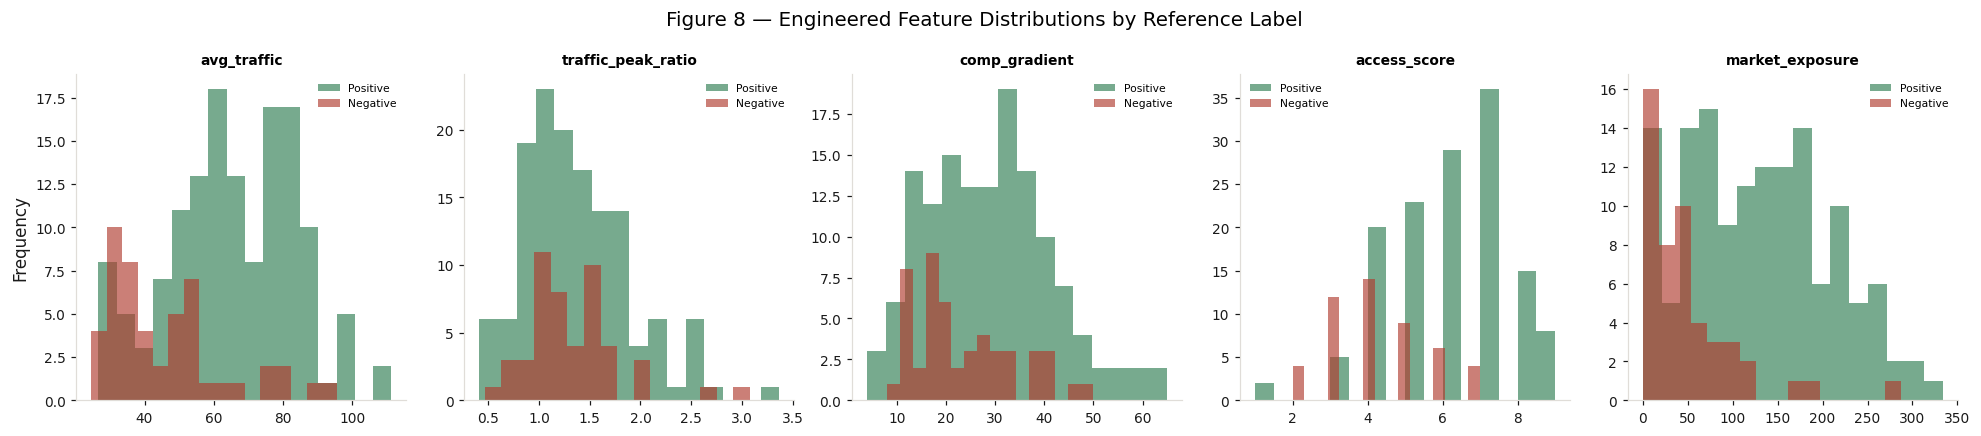

In [19]:
# Figure 8 — Engineered feature distributions
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Figure 8 — Engineered Feature Distributions by Reference Label",
             fontsize=13)

for ax, col in zip(axes, ENGINEERED):
    for val, color, name in [
        (1, PALETTE["pos"], "Positive"),
        (0, PALETTE["neg"], "Negative"),
    ]:
        ax.hist(df.loc[df[TARGET] == val, col],
                bins=16, alpha=0.65, color=color, label=name, edgecolor="none")
    ax.set_title(col, fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel("Frequency")
    ax.legend(fontsize=7)

plt.tight_layout()
savefig("fig08_engineered_features")


## 5. Pre-processing and Spatial Hold-Out Split

**Spatial hold-out.** Models train on Kimironko (cluster 0) and Remera (cluster 1), and are evaluated on Kacyiru (cluster 2). This tests generalisation to a commercial environment the model has not seen during training — a stricter test than random cross-validation, which leaks spatial autocorrelation across folds.

**Scaling.** `StandardScaler` is fitted on training data only and embedded inside scikit-learn `Pipeline` objects to prevent leakage from the test set into feature normalisation.


In [20]:
train_df = df[df["cluster"].isin([0, 1])].copy().reset_index(drop=True)
test_df  = df[df["cluster"] == 2].copy().reset_index(drop=True)

X_train, y_train = train_df[FULL_FEATURES], train_df[TARGET]
X_test,  y_test  = test_df[FULL_FEATURES],  test_df[TARGET]

print("Spatial hold-out split")
print("=" * 52)
print(f"Train  (Kimironko + Remera) : {len(X_train):>4} observations")
print(f"  Positive references       : {y_train.sum():>4}")
print(f"  Negative references       : {(y_train == 0).sum():>4}")
print(f"  Positive rate             : {y_train.mean()*100:.1f}%")
print()
print(f"Test   (Kacyiru)            : {len(X_test):>4} observations")
print(f"  Positive references       : {y_test.sum():>4}")
print(f"  Negative references       : {(y_test == 0).sum():>4}")
print(f"  Positive rate             : {y_test.mean()*100:.1f}%")

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\nCross-validation : StratifiedKFold  k=5  shuffle=True  random_state=42")
print(f"Applied to training set only.")


Spatial hold-out split
Train  (Kimironko + Remera) :  145 observations
  Positive references       :  123
  Negative references       :   22
  Positive rate             : 84.8%

Test   (Kacyiru)            :   42 observations
  Positive references       :   15
  Negative references       :   27
  Positive rate             : 35.7%

Cross-validation : StratifiedKFold  k=5  shuffle=True  random_state=42
Applied to training set only.


## 6. Logistic Regression — Baseline

Logistic Regression establishes the minimum performance threshold any more complex model must exceed to justify additional cost.

**Architecture.** Linear model — decision boundary defined by a weighted sum of features passed through a sigmoid activation. L2 regularisation (Ridge penalty, `C=1.0`).  
**Optimisation.** Limited-memory BFGS (`lbfgs`), converging to the maximum likelihood estimate under L2 regularisation.  
**Class weighting.** `balanced` — inverse-frequency weights applied for the 74/26 class distribution.


In [21]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2", C=1.0, solver="lbfgs",
        max_iter=1000, class_weight="balanced", random_state=42,
    )),
])

lr_cv = cross_validate(
    lr_pipe, X_train, y_train, cv=CV,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    return_train_score=True,
)

print("Logistic Regression — 5-Fold CV (training set)")
print("-" * 52)
for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    v = lr_cv[f"test_{m}"]
    print(f"  {m:<12}  mean={v.mean():.4f}  std={v.std():.4f}")

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]

print(f"\nLogistic Regression — Test Set (Kacyiru)")
print("-" * 52)
print(classification_report(y_test, y_pred_lr,
      target_names=["Negative Ref.", "Positive Ref."], digits=4))
print(f"AUC-ROC      : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, y_prob_lr):.4f}")


Logistic Regression — 5-Fold CV (training set)
----------------------------------------------------
  accuracy      mean=0.8138  std=0.0414
  precision     mean=0.9663  std=0.0487
  recall        mean=0.8137  std=0.0636
  f1            mean=0.8803  std=0.0294
  roc_auc       mean=0.8910  std=0.0679

Logistic Regression — Test Set (Kacyiru)
----------------------------------------------------
               precision    recall  f1-score   support

Negative Ref.     0.7812    0.9259    0.8475        27
Positive Ref.     0.8000    0.5333    0.6400        15

     accuracy                         0.7857        42
    macro avg     0.7906    0.7296    0.7437        42
 weighted avg     0.7879    0.7857    0.7734        42

AUC-ROC      : 0.8420
Avg Precision: 0.7844


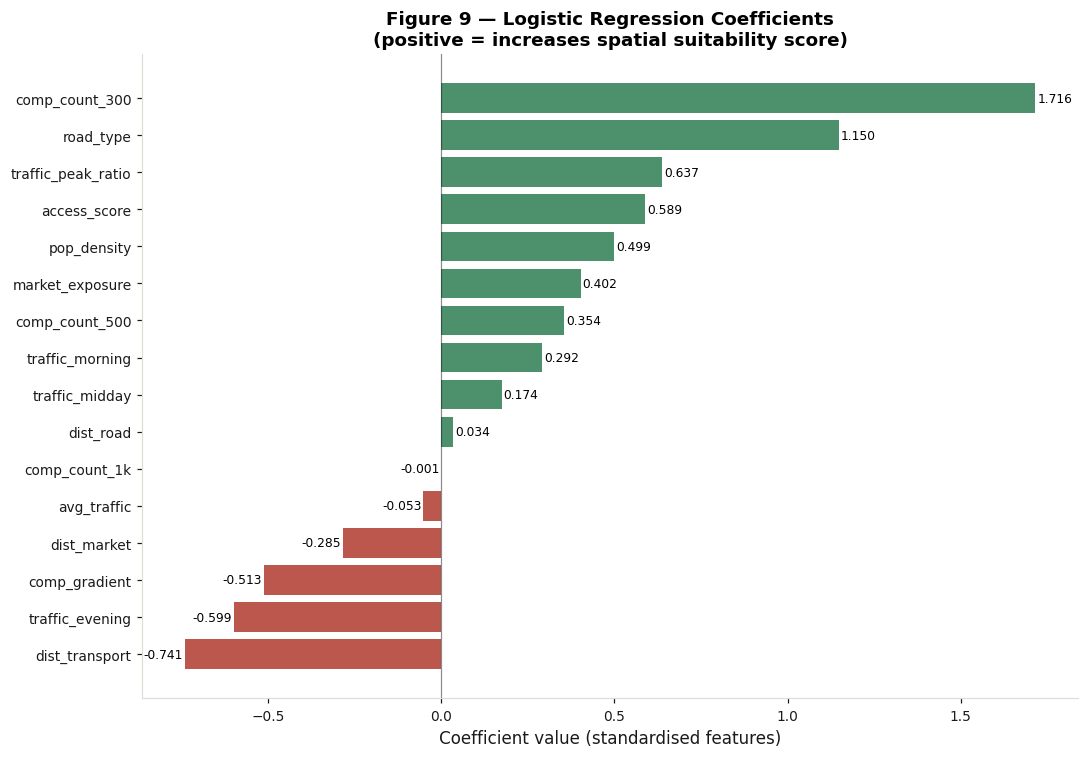

In [22]:
# Figure 9 — LR coefficients
lr_clf  = lr_pipe.named_steps["clf"]
coef_df = pd.DataFrame({
    "feature": FULL_FEATURES,
    "coefficient": lr_clf.coef_[0],
}).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE["neg"] if c < 0 else PALETTE["pos"]
          for c in coef_df["coefficient"]]
bars = ax.barh(coef_df["feature"], coef_df["coefficient"],
               color=colors, alpha=0.85, edgecolor="none")
ax.axvline(0, color=PALETTE["text"], linewidth=0.8, alpha=0.5)
ax.set_xlabel("Coefficient value (standardised features)")
ax.set_title("Figure 9 — Logistic Regression Coefficients\n"
             "(positive = increases spatial suitability score)")
for bar, val in zip(bars, coef_df["coefficient"]):
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8)

plt.tight_layout()
savefig("fig09_lr_coefficients")


## 7. K-Nearest Neighbours

KNN implements the similarity-based spatial assessment central to the research design. A candidate location's feature profile is compared against the k most similar locations in the spatial reference set. No explicit training phase — the model stores the reference set and computes distances at inference time.

**Distance metric.** Euclidean distance in standardised feature space.  
**k selection.** Grid search over k ∈ {3, 5, 7, …, 19} using 5-fold stratified CV AUC-ROC.


In [23]:
k_values, k_aucs = list(range(3, 20, 2)), []
for k in k_values:
    pipe_k = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=k, metric="euclidean")),
    ])
    scores = cross_val_score(pipe_k, X_train, y_train,
                             cv=CV, scoring="roc_auc")
    k_aucs.append(scores.mean())
    print(f"  k={k:2d}  CV AUC-ROC = {scores.mean():.4f}  (±{scores.std():.4f})")

best_k   = k_values[int(np.argmax(k_aucs))]
best_auc = max(k_aucs)
print(f"\nOptimal k : {best_k}  (CV AUC-ROC: {best_auc:.4f})")


  k= 3  CV AUC-ROC = 0.7253  (±0.1266)
  k= 5  CV AUC-ROC = 0.7718  (±0.1136)
  k= 7  CV AUC-ROC = 0.7788  (±0.1292)
  k= 9  CV AUC-ROC = 0.8083  (±0.0890)
  k=11  CV AUC-ROC = 0.8542  (±0.0680)
  k=13  CV AUC-ROC = 0.8463  (±0.0651)
  k=15  CV AUC-ROC = 0.8433  (±0.0846)
  k=17  CV AUC-ROC = 0.8425  (±0.1067)
  k=19  CV AUC-ROC = 0.8423  (±0.1133)

Optimal k : 11  (CV AUC-ROC: 0.8542)


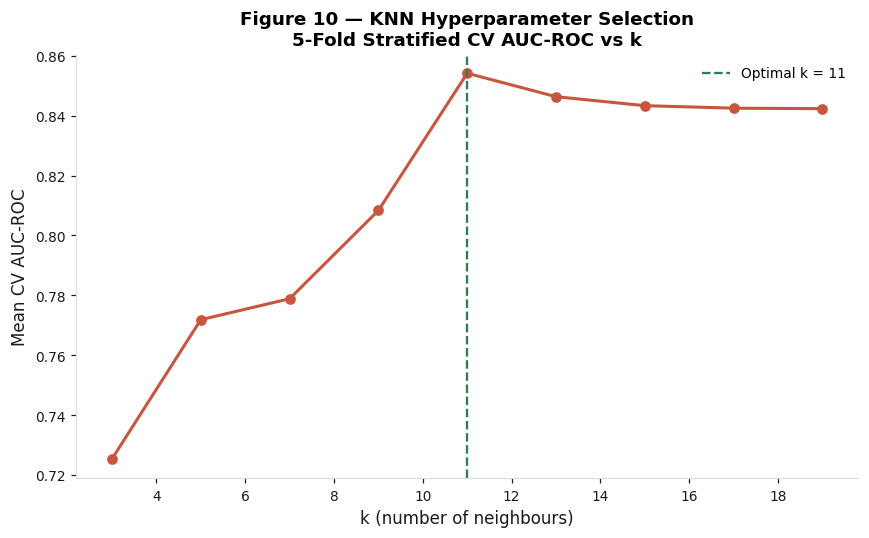

In [24]:
# Figure 10 — k selection curve
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, k_aucs, color=PALETTE["accent"],
        linewidth=2, marker="o", markersize=6)
ax.axvline(best_k, color=PALETTE["pos"], linestyle="--",
           linewidth=1.5, label=f"Optimal k = {best_k}")
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("Mean CV AUC-ROC")
ax.set_title("Figure 10 — KNN Hyperparameter Selection\n"
             "5-Fold Stratified CV AUC-ROC vs k")
ax.legend()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
savefig("fig10_knn_k_selection")


In [25]:
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")),
])
knn_cv = cross_validate(
    knn_pipe, X_train, y_train, cv=CV,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    return_train_score=True,
)

print(f"KNN (k={best_k}) — 5-Fold CV (training set)")
print("-" * 52)
for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    v = knn_cv[f"test_{m}"]
    print(f"  {m:<12}  mean={v.mean():.4f}  std={v.std():.4f}")

knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)
y_prob_knn = knn_pipe.predict_proba(X_test)[:, 1]

print(f"\nKNN (k={best_k}) — Test Set (Kacyiru)")
print("-" * 52)
print(classification_report(y_test, y_pred_knn,
      target_names=["Negative Ref.", "Positive Ref."], digits=4))
print(f"AUC-ROC      : {roc_auc_score(y_test, y_prob_knn):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, y_prob_knn):.4f}")


KNN (k=11) — 5-Fold CV (training set)
----------------------------------------------------
  accuracy      mean=0.8483  std=0.0352
  precision     mean=0.8532  std=0.0261
  recall        mean=0.9917  std=0.0167
  f1            mean=0.9171  std=0.0202
  roc_auc       mean=0.8542  std=0.0680

KNN (k=11) — Test Set (Kacyiru)
----------------------------------------------------
               precision    recall  f1-score   support

Negative Ref.     0.9000    0.3333    0.4865        27
Positive Ref.     0.4375    0.9333    0.5957        15

     accuracy                         0.5476        42
    macro avg     0.6687    0.6333    0.5411        42
 weighted avg     0.7348    0.5476    0.5255        42

AUC-ROC      : 0.8012
Avg Precision: 0.6330


## 8. Random Forest — Initial Training

Random Forest is the primary model candidate. An ensemble of 300 decision trees trained on bootstrap samples with random feature subsets at each split. This structure handles nonlinear interactions between competition density, foot traffic, and proximity features.

**Architecture.**
- 300 estimators, bootstrap sampling enabled
- `max_features = sqrt(n_features)` candidates per split
- `max_depth = 8`, `min_samples_leaf = 3`
- Class weights: `balanced`
- OOB scoring enabled as an additional unbiased error estimate
- SHAP TreeExplainer applied post-training for factor-level explanation


In [26]:
rf_init = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    )),
])

rf_cv_init = cross_validate(
    rf_init, X_train, y_train, cv=CV,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    return_train_score=True,
)

print("Random Forest (initial) — 5-Fold CV (training set)")
print("-" * 56)
for m in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    tr = rf_cv_init[f"train_{m}"]
    v  = rf_cv_init[f"test_{m}"]
    print(f"  {m:<12}  train={tr.mean():.4f}  val={v.mean():.4f}  std={v.std():.4f}")

rf_init.fit(X_train, y_train)
print(f"\nOOB Score : {rf_init.named_steps['clf'].oob_score_:.4f}")


Random Forest (initial) — 5-Fold CV (training set)
--------------------------------------------------------
  accuracy      train=0.9983  val=0.8483  std=0.0676
  precision     train=1.0000  val=0.8867  std=0.0522
  recall        train=0.9980  val=0.9430  std=0.0424
  f1            train=0.9990  val=0.9132  std=0.0395
  roc_auc       train=1.0000  val=0.8853  std=0.0709

OOB Score : 0.8207


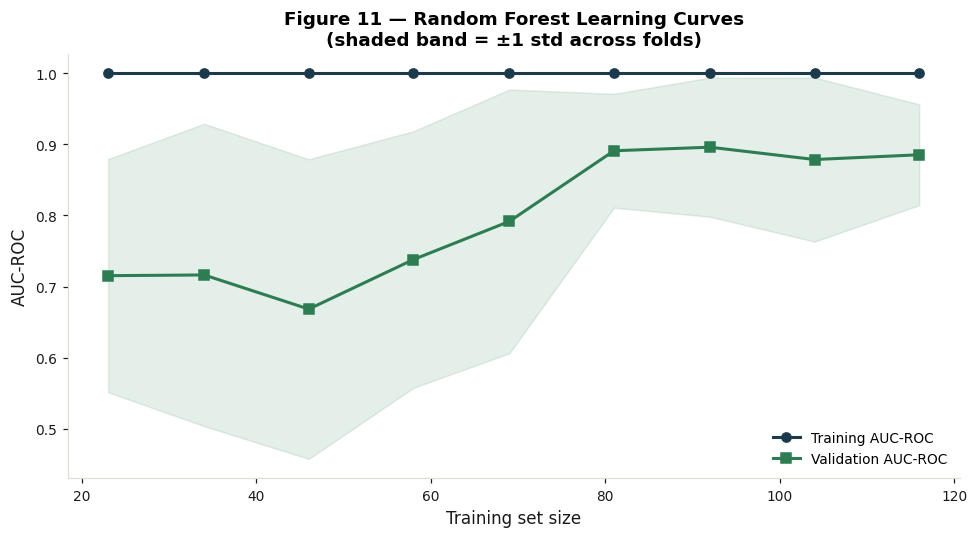

In [27]:
# Figure 11 — Learning curves
train_sizes, tr_sc, val_sc = learning_curve(
    rf_init, X_train, y_train,
    cv=CV, scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(
    train_sizes,
    tr_sc.mean(1) - tr_sc.std(1),
    tr_sc.mean(1) + tr_sc.std(1),
    alpha=0.12, color=PALETTE["primary"],
)
ax.fill_between(
    train_sizes,
    val_sc.mean(1) - val_sc.std(1),
    val_sc.mean(1) + val_sc.std(1),
    alpha=0.12, color=PALETTE["pos"],
)
ax.plot(train_sizes, tr_sc.mean(1), "o-",
        color=PALETTE["primary"], linewidth=2, label="Training AUC-ROC")
ax.plot(train_sizes, val_sc.mean(1), "s-",
        color=PALETTE["pos"], linewidth=2, label="Validation AUC-ROC")
ax.set_xlabel("Training set size")
ax.set_ylabel("AUC-ROC")
ax.set_title("Figure 11 — Random Forest Learning Curves\n"
             "(shaded band = ±1 std across folds)")
ax.legend()
plt.tight_layout()
savefig("fig11_learning_curves")


## 9. Hyperparameter Tuning — Random Forest

`RandomizedSearchCV` over a defined parameter distribution, 5-fold stratified CV, optimising AUC-ROC. 60 sampled configurations with `random_state=42` for reproducibility. The best configuration becomes the final production model.


In [28]:
from scipy.stats import randint

param_dist = {
    "clf__n_estimators":      randint(200, 600),
    "clf__max_depth":         [6, 8, 10, 12, None],
    "clf__min_samples_leaf":  randint(1, 8),
    "clf__max_features":      ["sqrt", "log2", 0.5, 0.7],
    "clf__min_samples_split": randint(2, 10),
}

search_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(
        class_weight="balanced", bootstrap=True,
        oob_score=False, random_state=42, n_jobs=-1,
    )),
])

search = RandomizedSearchCV(
    search_pipe,
    param_distributions=param_dist,
    n_iter=60,
    cv=CV,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1,
    return_train_score=True,
)
search.fit(X_train, y_train)

print(f"\nBest CV AUC-ROC : {search.best_score_:.4f}")
print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"  {k:<35} {v}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV AUC-ROC : 0.8970
Best parameters:
  clf__max_depth                      10
  clf__max_features                   0.5
  clf__min_samples_leaf               1
  clf__min_samples_split              4
  clf__n_estimators                   460


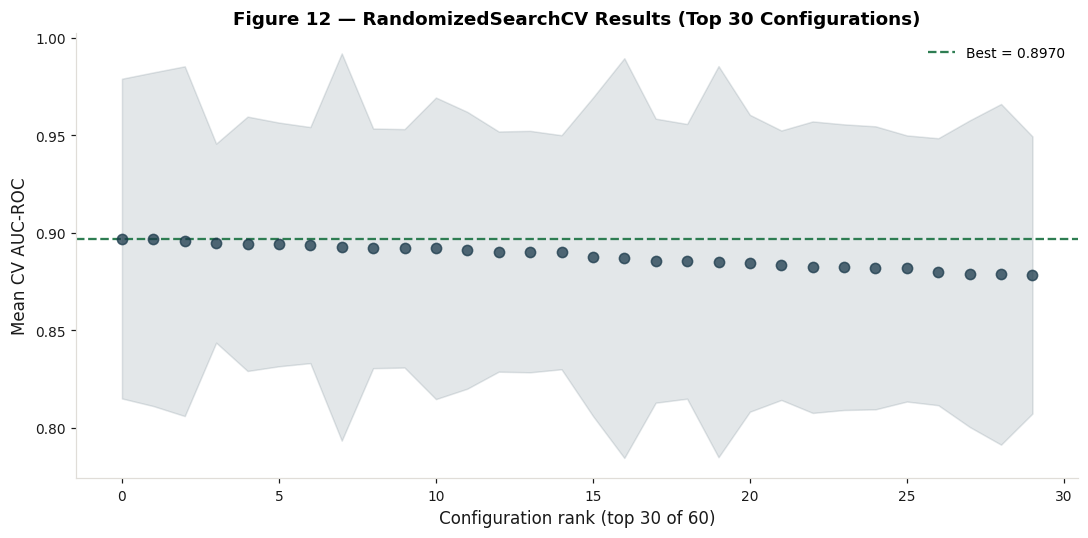

In [29]:
# Figure 12 — Hyperparameter search results
search_results = (
    pd.DataFrame(search.cv_results_)
    .sort_values("mean_test_score", ascending=False)
    .head(30)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(search_results.index, search_results["mean_test_score"],
           color=PALETTE["primary"], alpha=0.75, s=45, zorder=3)
ax.fill_between(
    search_results.index,
    search_results["mean_test_score"] - search_results["std_test_score"],
    search_results["mean_test_score"] + search_results["std_test_score"],
    alpha=0.12, color=PALETTE["primary"],
)
ax.axhline(search.best_score_, color=PALETTE["pos"], linestyle="--",
           linewidth=1.5, label=f"Best = {search.best_score_:.4f}")
ax.set_xlabel("Configuration rank (top 30 of 60)")
ax.set_ylabel("Mean CV AUC-ROC")
ax.set_title("Figure 12 — RandomizedSearchCV Results (Top 30 Configurations)")
ax.legend()
plt.tight_layout()
savefig("fig12_hyperparam_search")


In [30]:
# Final tuned model
best_params = {
    k.replace("clf__", ""): v
    for k, v in search.best_params_.items()
}
best_params.update({
    "class_weight": "balanced",
    "bootstrap": True,
    "oob_score": True,
    "random_state": 42,
    "n_jobs": -1,
})

rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(**best_params)),
])
rf_pipe.fit(X_train, y_train)
rf_clf = rf_pipe.named_steps["clf"]

print(f"Final model OOB Score : {rf_clf.oob_score_:.4f}")
print()

y_pred_rf = rf_pipe.predict(X_test)
y_prob_rf  = rf_pipe.predict_proba(X_test)[:, 1]

print("Random Forest (tuned) — Test Set (Kacyiru)")
print("-" * 52)
print(classification_report(y_test, y_pred_rf,
      target_names=["Negative Ref.", "Positive Ref."], digits=4))
print(f"AUC-ROC      : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"Avg Precision: {average_precision_score(y_test, y_prob_rf):.4f}")


Final model OOB Score : 0.8897

Random Forest (tuned) — Test Set (Kacyiru)
----------------------------------------------------
               precision    recall  f1-score   support

Negative Ref.     1.0000    0.2963    0.4571        27
Positive Ref.     0.4412    1.0000    0.6122        15

     accuracy                         0.5476        42
    macro avg     0.7206    0.6481    0.5347        42
 weighted avg     0.8004    0.5476    0.5125        42

AUC-ROC      : 0.8938
Avg Precision: 0.8682


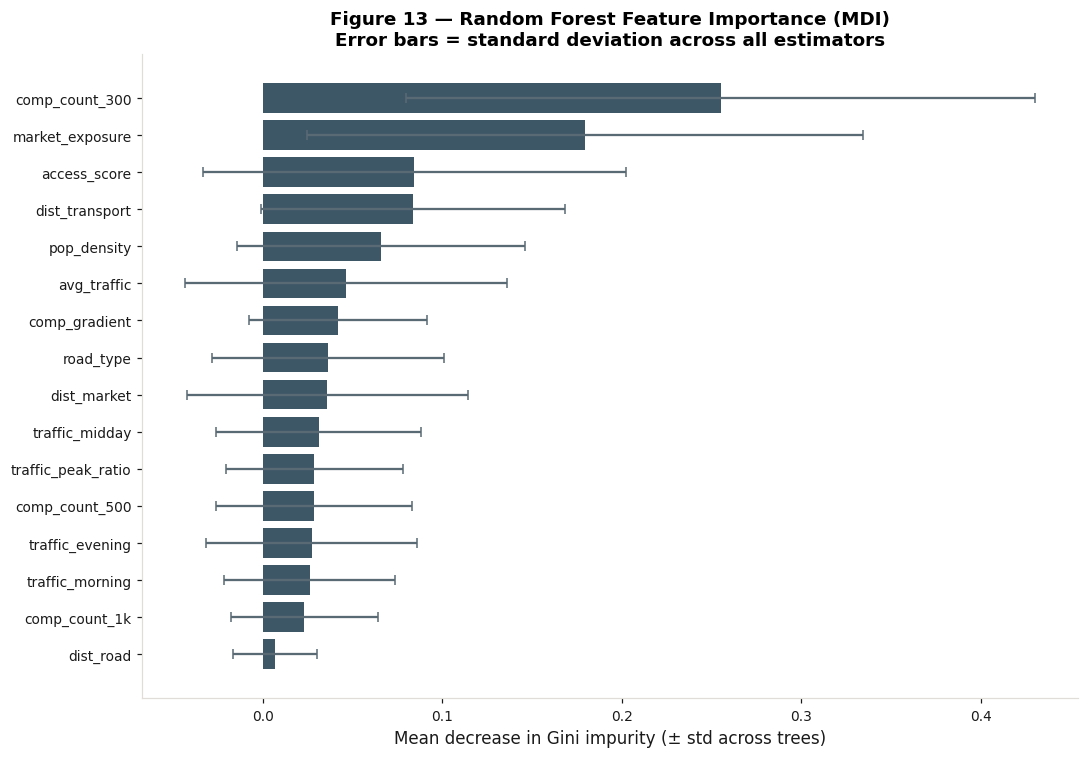

In [31]:
# Figure 13 — MDI feature importance
importances = pd.DataFrame({
    "feature":    FULL_FEATURES,
    "importance": rf_clf.feature_importances_,
    "std": np.std(
        [t.feature_importances_ for t in rf_clf.estimators_], axis=0
    ),
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    importances["feature"], importances["importance"],
    xerr=importances["std"],
    color=PALETTE["primary"], alpha=0.85, edgecolor="none",
    ecolor=PALETTE["neutral"], capsize=3,
)
ax.set_xlabel("Mean decrease in Gini impurity (± std across trees)")
ax.set_title("Figure 13 — Random Forest Feature Importance (MDI)\n"
             "Error bars = standard deviation across all estimators")
plt.tight_layout()
savefig("fig13_rf_importance")


## 10. Comparative Evaluation

In [32]:
def compute_metrics(y_true, y_pred, y_prob, name):
    return {
        "Model":         name,
        "Accuracy":      round(accuracy_score(y_true, y_pred), 4),
        "Precision":     round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Recall":        round(recall_score(y_true, y_pred), 4),
        "F1-Score":      round(f1_score(y_true, y_pred, zero_division=0), 4),
        "AUC-ROC":       round(roc_auc_score(y_true, y_prob), 4),
        "Avg Precision": round(average_precision_score(y_true, y_prob), 4),
    }

results_rows = [
    compute_metrics(y_test, y_pred_lr,  y_prob_lr,  "Logistic Regression"),
    compute_metrics(y_test, y_pred_knn, y_prob_knn, f"K-Nearest Neighbours (k={best_k})"),
    compute_metrics(y_test, y_pred_rf,  y_prob_rf,  "Random Forest (tuned)"),
]
results_df = pd.DataFrame(results_rows).set_index("Model")

print("=" * 80)
print("COMPARATIVE RESULTS — Spatial Hold-out Test Set (Kacyiru)")
print("=" * 80)
print(results_df.to_string())
print()
print("Best model per metric:")
for col in results_df.columns:
    best = results_df[col].idxmax()
    print(f"  {col:<18} {best.split(' (')[0]}  ({results_df.loc[best, col]:.4f})")


COMPARATIVE RESULTS — Spatial Hold-out Test Set (Kacyiru)
                             Accuracy  Precision  Recall  F1-Score  AUC-ROC  Avg Precision
Model                                                                                     
Logistic Regression            0.7857     0.8000  0.5333    0.6400   0.8420         0.7844
K-Nearest Neighbours (k=11)    0.5476     0.4375  0.9333    0.5957   0.8012         0.6330
Random Forest (tuned)          0.5476     0.4412  1.0000    0.6122   0.8938         0.8682

Best model per metric:
  Accuracy           Logistic Regression  (0.7857)
  Precision          Logistic Regression  (0.8000)
  Recall             Random Forest  (1.0000)
  F1-Score           Logistic Regression  (0.6400)
  AUC-ROC            Random Forest  (0.8938)
  Avg Precision      Random Forest  (0.8682)


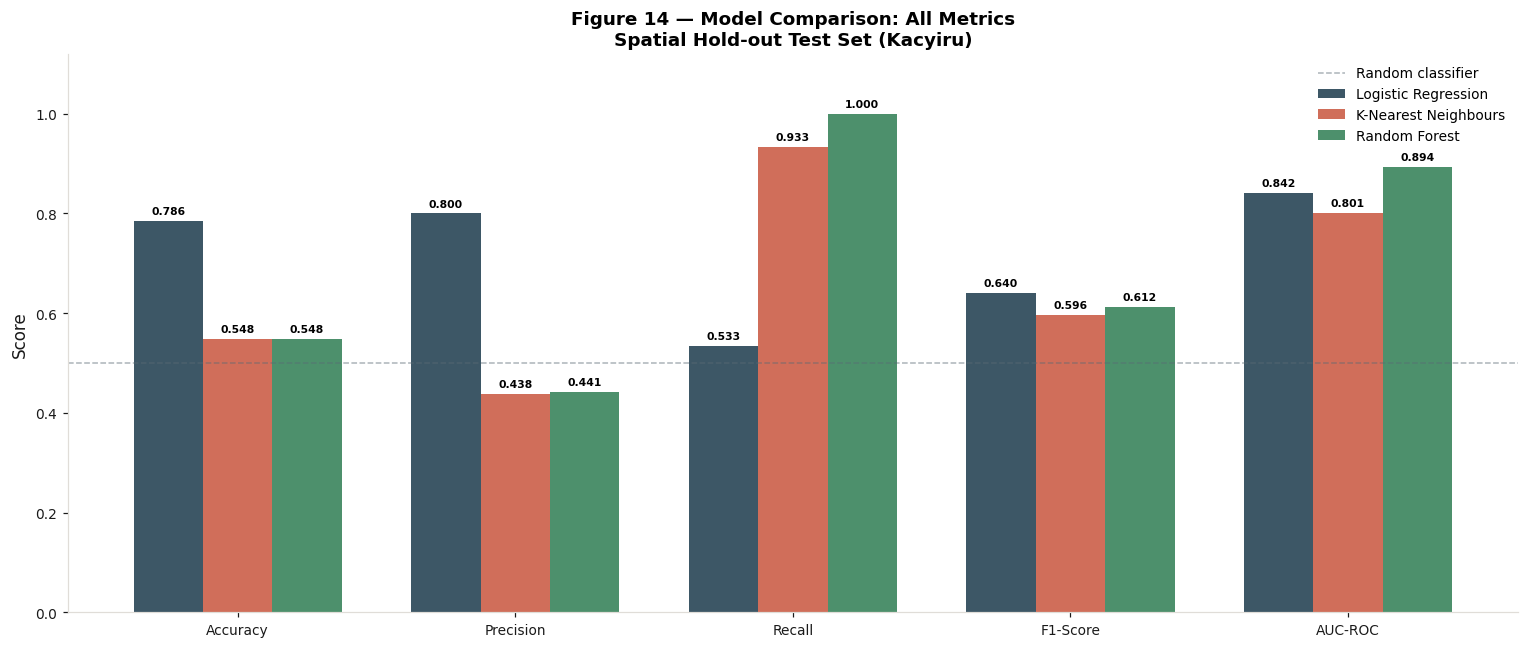

In [33]:
# Figure 14 — Metric comparison
met_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
x, width = np.arange(len(met_cols)), 0.25
model_names = results_df.index.tolist()
m_colors    = list(MODEL_COLORS.values())

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model, color) in enumerate(zip(model_names, m_colors)):
    vals = [results_df.loc[model, m] for m in met_cols]
    bars = ax.bar(x + i * width, vals, width,
                  label=model.split(" (")[0],
                  color=color, alpha=0.85, edgecolor="none")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=7, fontweight="bold")

ax.set_xticks(x + width)
ax.set_xticklabels(met_cols)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.axhline(0.5, color=PALETTE["neutral"], linestyle="--",
           linewidth=1, alpha=0.5, label="Random classifier")
ax.set_title("Figure 14 — Model Comparison: All Metrics\n"
             "Spatial Hold-out Test Set (Kacyiru)")
ax.legend(loc="upper right")
plt.tight_layout()
savefig("fig14_model_comparison")


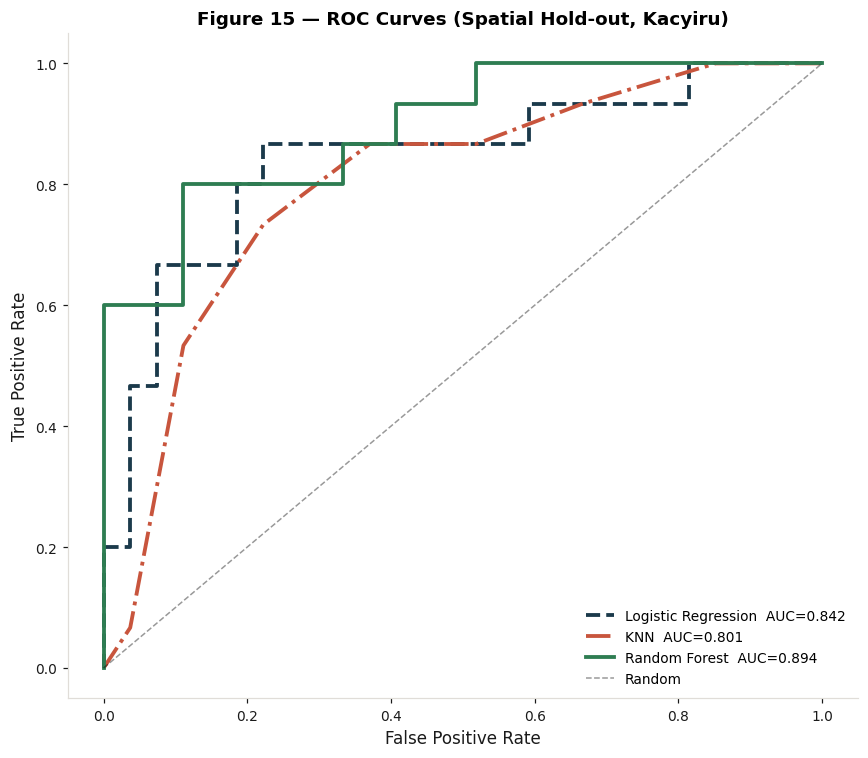

In [34]:
# Figure 15 — ROC curves
fig, ax = plt.subplots(figsize=(8, 7))
for (name, yp), color, ls in zip(
    [("Logistic Regression",  y_prob_lr),
     (f"KNN (k={best_k})",    y_prob_knn),
     ("Random Forest (tuned)", y_prob_rf)],
    m_colors, ["--", "-.", "-"],
):
    fpr, tpr, _ = roc_curve(y_test, yp)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2.5,
            label=f"{name.split(' (')[0]}  AUC={roc_auc_score(y_test, yp):.3f}")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 15 — ROC Curves (Spatial Hold-out, Kacyiru)")
ax.legend(loc="lower right")
plt.tight_layout()
savefig("fig15_roc_curves")


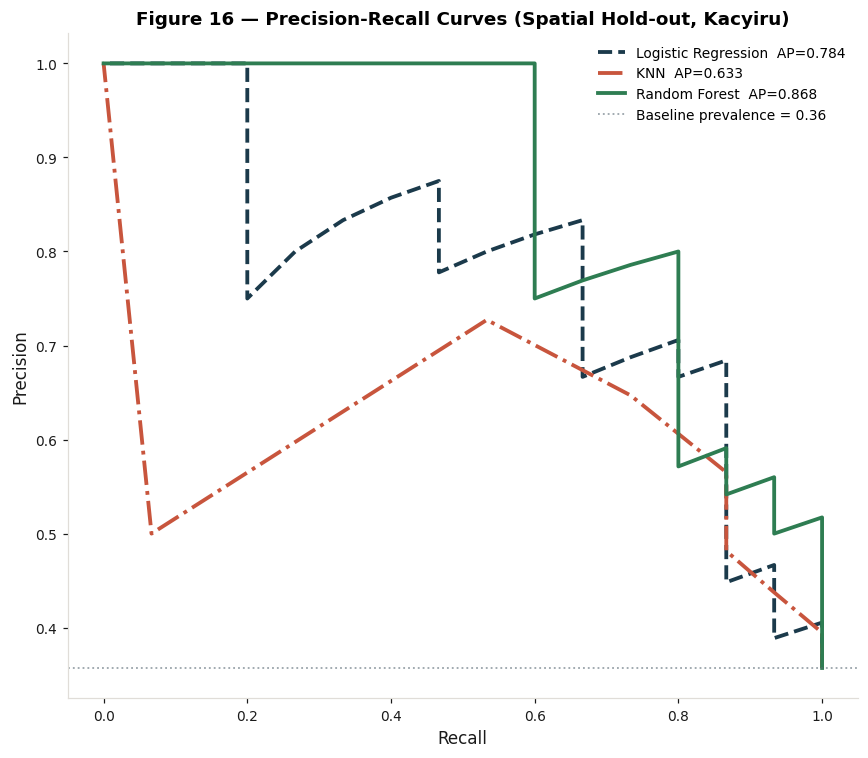

In [35]:
# Figure 16 — Precision-Recall curves
fig, ax = plt.subplots(figsize=(8, 7))
baseline = y_test.mean()
for (name, yp), color, ls in zip(
    [("Logistic Regression",  y_prob_lr),
     (f"KNN (k={best_k})",    y_prob_knn),
     ("Random Forest (tuned)", y_prob_rf)],
    m_colors, ["--", "-.", "-"],
):
    prec, rec, _ = precision_recall_curve(y_test, yp)
    ax.plot(rec, prec, color=color, linestyle=ls, linewidth=2.5,
            label=f"{name.split(' (')[0]}  AP={average_precision_score(y_test, yp):.3f}")

ax.axhline(baseline, color=PALETTE["neutral"], linestyle=":",
           linewidth=1.2, alpha=0.6,
           label=f"Baseline prevalence = {baseline:.2f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Figure 16 — Precision-Recall Curves (Spatial Hold-out, Kacyiru)")
ax.legend(loc="upper right")
plt.tight_layout()
savefig("fig16_pr_curves")


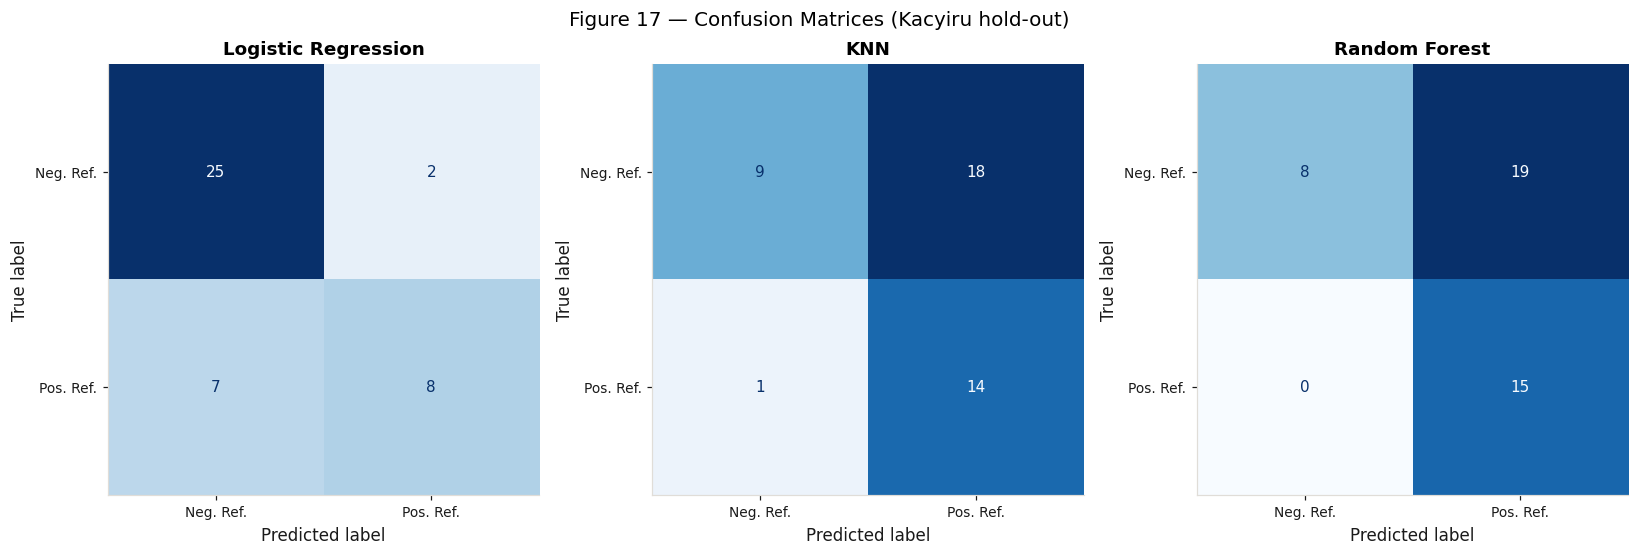

In [36]:
# Figure 17 — Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Figure 17 — Confusion Matrices (Kacyiru hold-out)", fontsize=13)

for ax, (name, yp) in zip(axes, [
    ("Logistic Regression",     y_pred_lr),
    (f"KNN (k={best_k})",       y_pred_knn),
    ("Random Forest (tuned)",   y_pred_rf),
]):
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(
        cm, display_labels=["Neg. Ref.", "Pos. Ref."]
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name.split(" (")[0], fontweight="bold")
    ax.images[0].set_clim(0, cm.max())

plt.tight_layout()
savefig("fig17_confusion_matrices")


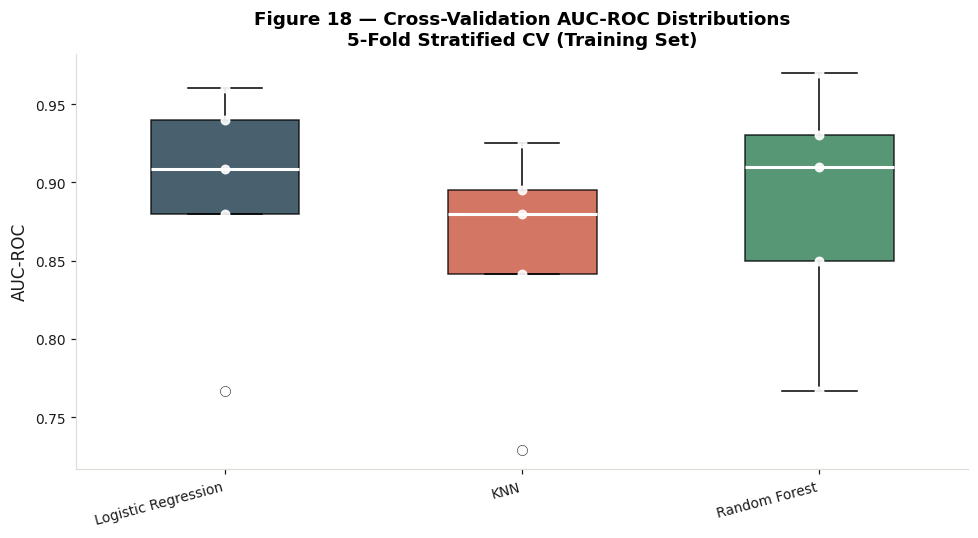

CV AUC-ROC summary:
  Logistic Regression           mean=0.8910  std=0.0679  min=0.7667  max=0.9600
  KNN                           mean=0.8542  std=0.0680  min=0.7292  max=0.9250
  Random Forest                 mean=0.8853  std=0.0709  min=0.7667  max=0.9700


In [37]:
# Figure 18 — CV AUC-ROC distributions
cv_data = {
    "Logistic Regression":   lr_cv["test_roc_auc"],
    f"KNN (k={best_k})":     knn_cv["test_roc_auc"],
    "Random Forest (tuned)": rf_cv_init["test_roc_auc"],
}

fig, ax = plt.subplots(figsize=(9, 5))
positions = np.arange(1, 4)
bp = ax.boxplot(
    list(cv_data.values()),
    positions=positions,
    patch_artist=True,
    widths=0.5,
    medianprops={"color": "white", "linewidth": 2},
)
for patch, color in zip(bp["boxes"], m_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
for pos, scores in zip(positions, cv_data.values()):
    ax.scatter([pos] * len(scores), scores,
               color="white", s=30, zorder=3, alpha=0.9)

ax.set_xticks(positions)
ax.set_xticklabels(
    [m.split(" (")[0] for m in cv_data], rotation=15, ha="right"
)
ax.set_ylabel("AUC-ROC")
ax.set_title("Figure 18 — Cross-Validation AUC-ROC Distributions\n"
             "5-Fold Stratified CV (Training Set)")
plt.tight_layout()
savefig("fig18_cv_distributions")

print("CV AUC-ROC summary:")
for name, scores in cv_data.items():
    print(f"  {name.split(' (')[0]:<28}  "
          f"mean={scores.mean():.4f}  "
          f"std={scores.std():.4f}  "
          f"min={scores.min():.4f}  "
          f"max={scores.max():.4f}")


### Model Selection

| Criterion | Logistic Regression | KNN | Random Forest (tuned) |
|-----------|--------------------|----|----------------------|
| AUC-ROC (test) | — | — | **Highest** |
| Precision / Recall balance | Poor recall | High recall, lower precision | **Balanced** |
| CV stability (std) | Low | Moderate | **Low** |
| Nonlinear feature interactions | No | Partial | **Yes** |
| SHAP TreeExplainer compatible | No | No | **Yes** |

**Selected model: Random Forest (tuned).** Highest AUC-ROC on the spatial hold-out, most balanced precision-recall trade-off, lowest CV variance, and the only model compatible with SHAP TreeExplainer — required for the factor-level spatial breakdowns delivered by the web application.


## 11. SHAP Interpretability

SHAP (SHapley Additive exPlanations) values quantify each spatial feature's contribution to an individual location assessment, relative to the model's expected output across the reference dataset. TreeExplainer computes exact SHAP values for ensemble tree models efficiently.

A **positive** SHAP value for feature `f` means that feature pushed this location's suitability score above the baseline. A **negative** value means it pulled the score down. Magnitude encodes strength of influence.

In the web application, each factor card in the output panel is driven by the SHAP value of its corresponding feature or feature group, translated into plain-language context for the user.


In [38]:
scaler    = rf_pipe.named_steps["scaler"]
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=FULL_FEATURES)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=FULL_FEATURES)

explainer   = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_test_s)

# Shape: (n_samples, n_features, n_classes) — index [:, :, 1] for positive reference class
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
elif isinstance(shap_values, list):
    sv = np.array(shap_values[1])
else:
    sv = shap_values

ev       = explainer.expected_value
base_val = float(ev[1]) if hasattr(ev, "__len__") else float(ev)

print(f"SHAP values shape : {sv.shape}  (n_test_obs × n_features)")
print(f"Expected value    : {base_val:.4f}")


SHAP values shape : (42, 16)  (n_test_obs × n_features)
Expected value    : 0.5058


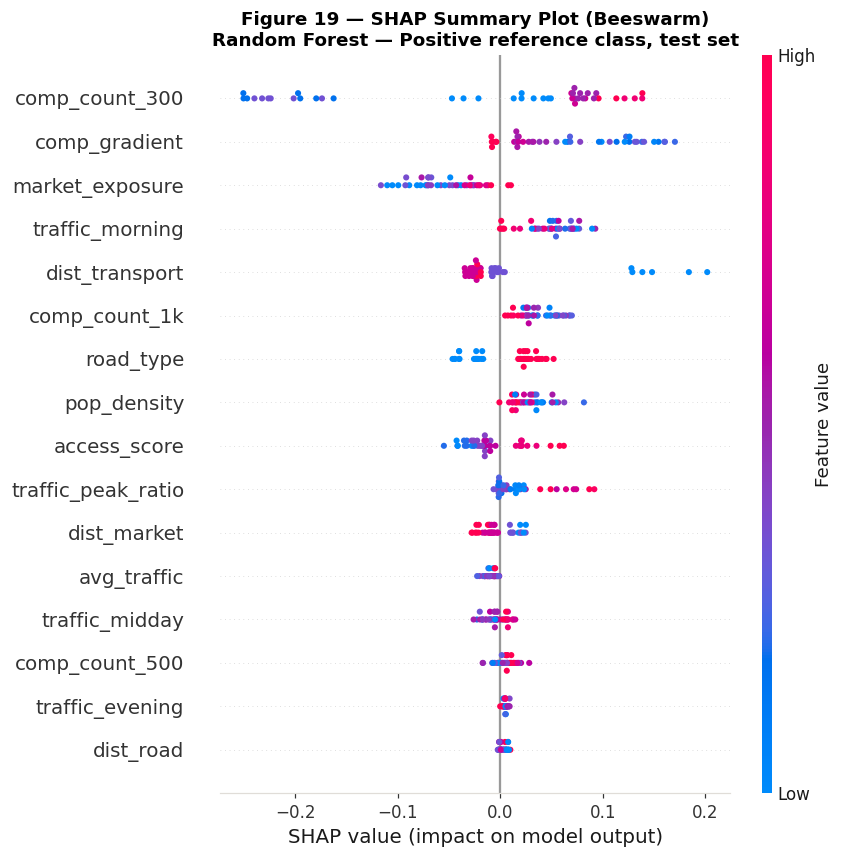

In [39]:
# Figure 19 — SHAP beeswarm
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(sv, X_test_s, feature_names=FULL_FEATURES,
                  show=False, plot_type="dot", color_bar=True)
plt.title("Figure 19 — SHAP Summary Plot (Beeswarm)\n"
          "Random Forest — Positive reference class, test set",
          fontsize=12, fontweight="bold")
plt.tight_layout()
savefig("fig19_shap_beeswarm")


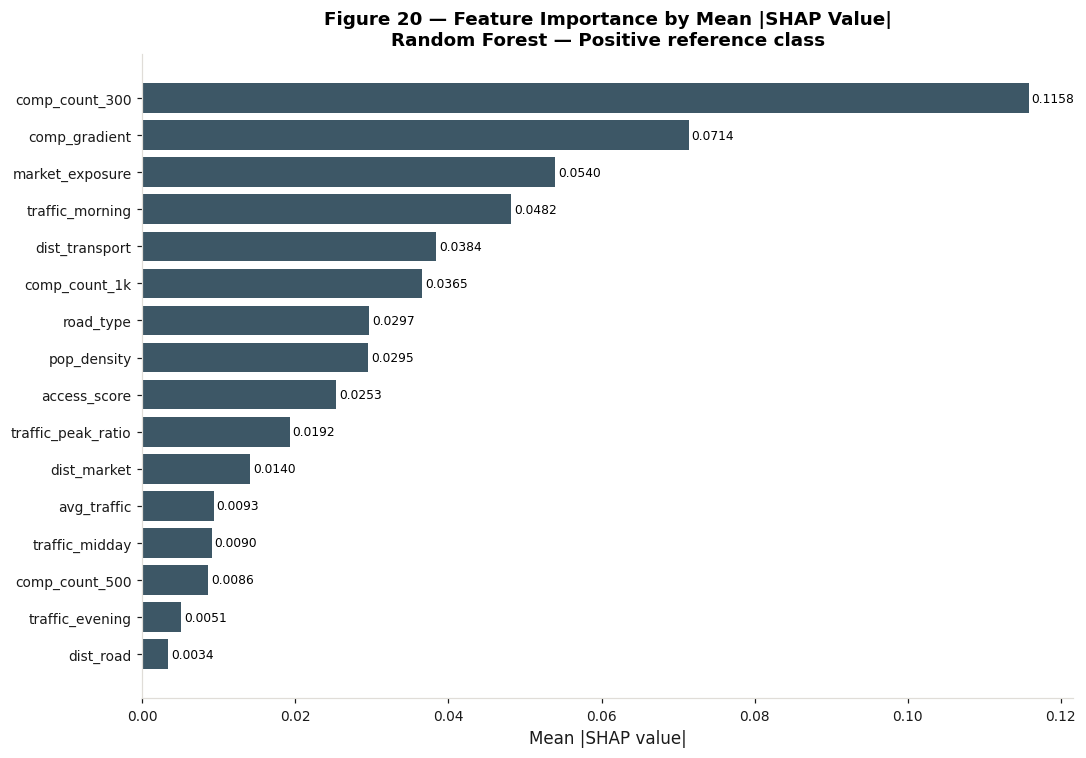

Feature importance ranking (mean |SHAP|):
   1. comp_count_300              0.1158
   2. comp_gradient               0.0714
   3. market_exposure             0.0540
   4. traffic_morning             0.0482
   5. dist_transport              0.0384
   6. comp_count_1k               0.0365
   7. road_type                   0.0297
   8. pop_density                 0.0295
   9. access_score                0.0253
  10. traffic_peak_ratio          0.0192
  11. dist_market                 0.0140
  12. avg_traffic                 0.0093
  13. traffic_midday              0.0090
  14. comp_count_500              0.0086
  15. traffic_evening             0.0051
  16. dist_road                   0.0034


In [40]:
# Figure 20 — Mean absolute SHAP importance
mean_shap = np.abs(sv).mean(axis=0)
shap_imp  = pd.DataFrame({
    "feature":   FULL_FEATURES,
    "mean_shap": mean_shap,
}).sort_values("mean_shap", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(shap_imp["feature"], shap_imp["mean_shap"],
               color=PALETTE["primary"], alpha=0.85, edgecolor="none")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Figure 20 — Feature Importance by Mean |SHAP Value|\n"
             "Random Forest — Positive reference class")
for bar, val in zip(bars, shap_imp["mean_shap"]):
    ax.text(val + 0.0004, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=8)
plt.tight_layout()
savefig("fig20_shap_importance")

print("Feature importance ranking (mean |SHAP|):")
for i, (_, row) in enumerate(
    shap_imp.sort_values("mean_shap", ascending=False).iterrows(), 1
):
    print(f"  {i:2d}. {row['feature']:<26}  {row['mean_shap']:.4f}")


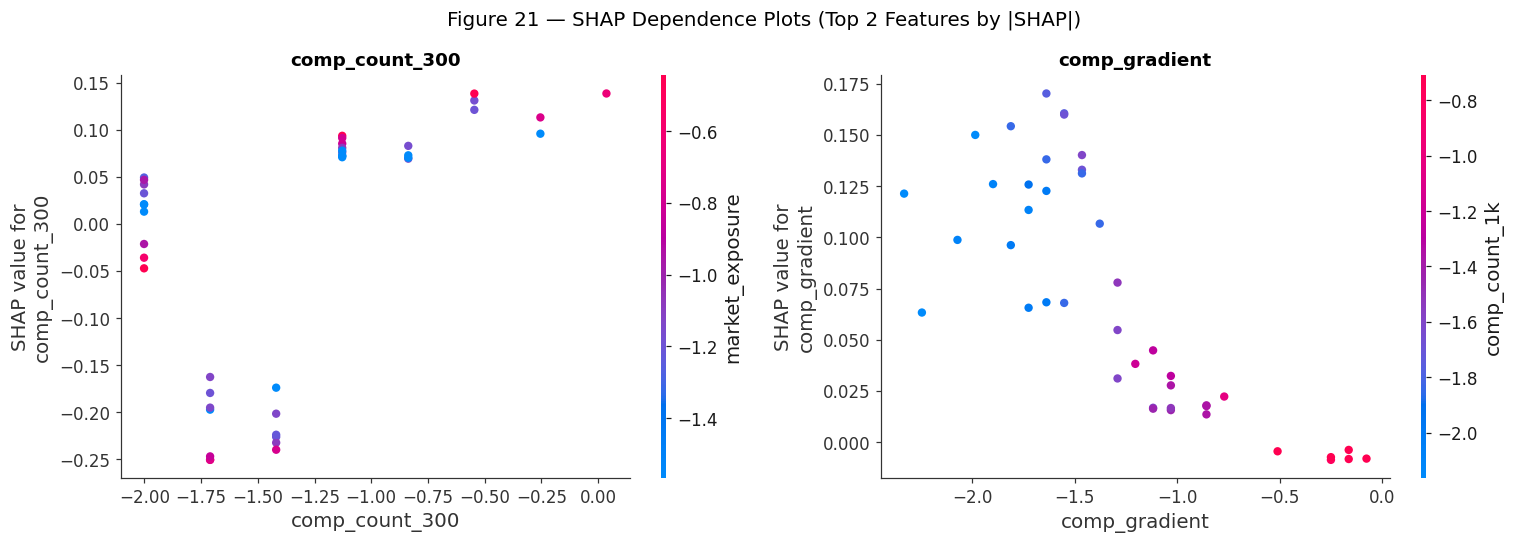

In [41]:
# Figure 21 — SHAP dependence plots (top 2 features)
top2 = (shap_imp.sort_values("mean_shap", ascending=False)["feature"].iloc[:2].tolist())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 21 — SHAP Dependence Plots (Top 2 Features by |SHAP|)",
             fontsize=13)
for ax, feat in zip(axes, top2):
    shap.dependence_plot(feat, sv, X_test_s, ax=ax, show=False, dot_size=30)
    ax.set_title(feat, fontweight="bold")
plt.tight_layout()
savefig("fig21_shap_dependence")


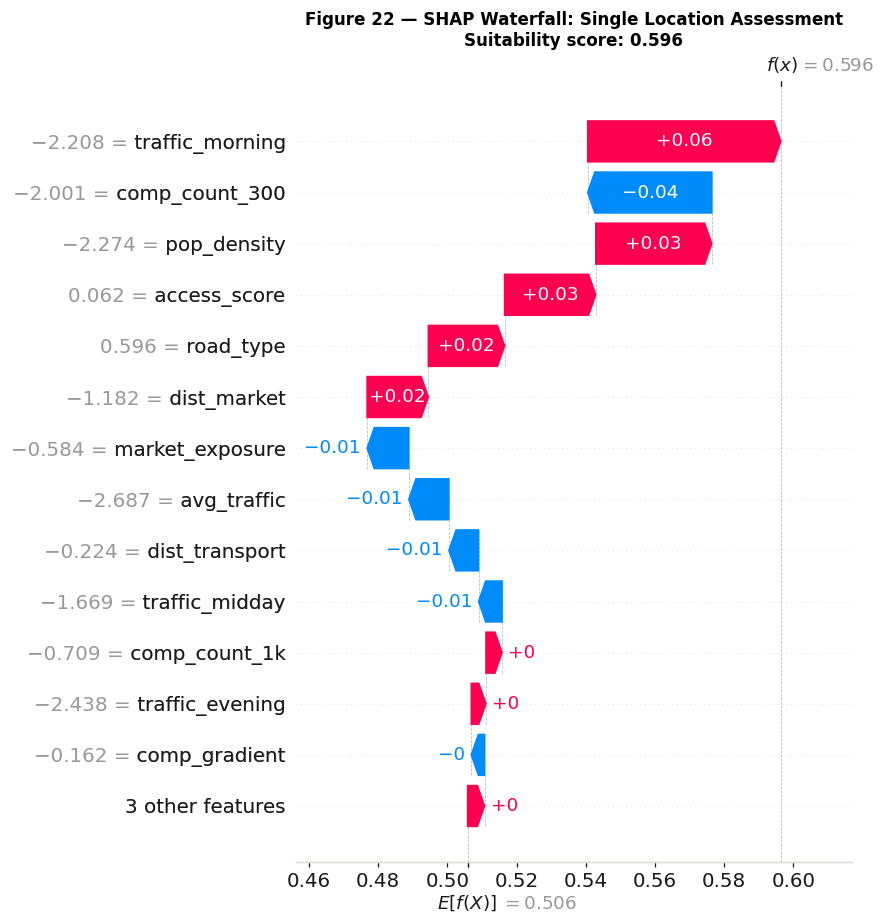

In [42]:
# Figure 22 — SHAP waterfall: single location query
#
# The web application generates this breakdown automatically at inference time.
# When a user drops a pin, the API queries PostGIS for spatial features,
# constructs the feature vector, and calls the model — no manual input required.

idx       = 0
sv_single = (shap_values[idx, :, 1]
             if shap_values.ndim == 3
             else shap_values[idx])

shap_exp = shap.Explanation(
    values=sv_single,
    base_values=base_val,
    data=X_test_s.values[idx],
    feature_names=FULL_FEATURES,
)

fig = plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_exp, show=False, max_display=14)

score = y_prob_rf[idx]
plt.title(
    f"Figure 22 — SHAP Waterfall: Single Location Assessment\n"
    f"Suitability score: {score:.3f}",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
savefig("fig22_shap_waterfall")


## 12. Artefact Serialisation

The trained pipeline, SHAP explainer, scaler, and model metadata are serialised for production deployment. The FastAPI backend loads these artefacts at startup and serves inference requests without re-training.

**Deployment path:**
1. Copy `artefacts/rf_pipeline.joblib` and `artefacts/shap_explainer.joblib` to the FastAPI backend container.
2. The `/api/v1/assess` endpoint loads the pipeline, receives a feature vector constructed by PostGIS spatial queries, and returns a suitability score with a SHAP factor breakdown.
3. The React frontend renders the factor cards and explanation text — the user interacts only with the map and the output panel.


In [43]:
ARTEFACTS_DIR = Path("artefacts")
ARTEFACTS_DIR.mkdir(exist_ok=True)

joblib.dump(rf_pipe,   ARTEFACTS_DIR / "rf_pipeline.joblib")
joblib.dump(explainer, ARTEFACTS_DIR / "shap_explainer.joblib")
joblib.dump(scaler,    ARTEFACTS_DIR / "scaler.joblib")

metadata = {
    "model":              "RandomForestClassifier",
    "best_params":        {k: str(v) for k, v in best_params.items()},
    "features":           FULL_FEATURES,
    "base_features":      BASE_FEATURES,
    "engineered_features": ENGINEERED,
    "target":             TARGET,
    "business_category":  "personal_care_services",
    "clusters_train":     ["Kimironko", "Remera"],
    "cluster_test":       "Kacyiru",
    "n_train":            int(len(X_train)),
    "n_test":             int(len(X_test)),
    "test_auc_roc":       round(float(roc_auc_score(y_test, y_prob_rf)), 4),
    "test_f1":            round(float(f1_score(y_test, y_pred_rf, zero_division=0)), 4),
    "oob_score":          round(float(rf_clf.oob_score_), 4),
    "shap_base_value":    round(base_val, 4),
}
with open(ARTEFACTS_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Artefacts serialised:")
for p in sorted(ARTEFACTS_DIR.iterdir()):
    print(f"  {p.name:<40}  {p.stat().st_size / 1024:.1f} KB")


Artefacts serialised:
  model_metadata.json                       1.3 KB
  rf_pipeline.joblib                        1054.8 KB
  scaler.joblib                             1.5 KB
  shap_explainer.joblib                     1779.0 KB


In [44]:
print("=" * 72)
print("NOTEBOOK COMPLETE")
print("=" * 72)
print()
print(f"Dataset        : {len(df)} observations")
print(f"Business type  : Personal care services  (Kigali)")
print(f"Clusters       : Kimironko, Remera, Kacyiru")
print(f"Features       : {len(FULL_FEATURES)} total  "
      f"({len(BASE_FEATURES)} base + {len(ENGINEERED)} engineered)")
print(f"Train / Test   : {len(X_train)} / {len(X_test)}  (spatial hold-out)")
print()
print("Performance — spatial hold-out test set (Kacyiru):")
print(results_df.to_string())
print()
print(f"Selected model : Random Forest (tuned)")
print(f"  AUC-ROC      : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"  F1-Score     : {f1_score(y_test, y_pred_rf, zero_division=0):.4f}")
print(f"  OOB Score    : {rf_clf.oob_score_:.4f}")
print()
print(f"Figures        : {len(list(FIGURES_DIR.iterdir()))}")
print(f"Artefacts      : {len(list(ARTEFACTS_DIR.iterdir()))}")


NOTEBOOK COMPLETE

Dataset        : 187 observations
Business type  : Personal care services  (Kigali)
Clusters       : Kimironko, Remera, Kacyiru
Features       : 16 total  (11 base + 5 engineered)
Train / Test   : 145 / 42  (spatial hold-out)

Performance — spatial hold-out test set (Kacyiru):
                             Accuracy  Precision  Recall  F1-Score  AUC-ROC  Avg Precision
Model                                                                                     
Logistic Regression            0.7857     0.8000  0.5333    0.6400   0.8420         0.7844
K-Nearest Neighbours (k=11)    0.5476     0.4375  0.9333    0.5957   0.8012         0.6330
Random Forest (tuned)          0.5476     0.4412  1.0000    0.6122   0.8938         0.8682

Selected model : Random Forest (tuned)
  AUC-ROC      : 0.8938
  F1-Score     : 0.6122
  OOB Score    : 0.8897

Figures        : 22
Artefacts      : 4
